In [1]:
from langchain.chat_models import init_chat_model 
from typing_extensions import TypedDict , Literal
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph , START , END
from IPython.display import Image, display
from langchain.messages import HumanMessage, SystemMessage
from dotenv import load_dotenv

load_dotenv()  # Load environment variables from .env file

True

In [ ]:
model = init_chat_model(
    model_provider="google_genai", 
                        model ="gemini-2.5-flash",
                        temperature=0.7,
                        max_output_tokens=1024,
                        top_p=0.95,
                        top_k=40,
                        timeout = 30,
                        max_retries = 3,
                        load_env=True
)

In [3]:
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )

In [4]:
router = model.with_structured_output(Route)

In [5]:
class State(TypedDict):
    input : str 
    decision : str 
    output : str

In [6]:
def llm_call1(state = State):
    """Write a story based on the input."""

    result = model.invoke(state["input"])
    return {'output' : result.content}

In [7]:
def llm_call2(state = State):
    """Write a joke based on the input."""

    result = model.invoke(state["input"])
    return {'output': result.content}

In [8]:
def llm_call3(state = State):
    """Write a poem based on the input."""

    result = model.invoke(state["input"])
    return {'output': result.content}

In [9]:
def llm_call_router(state = State):
    """Route the input to the appropriate node"""

    decision = router.invoke(
        [
            SystemMessage(content="You are a routing model that decides whether the input is a poem, story, or joke."),
            HumanMessage(content=state["input"])
        ]
    )

    return {'decision' : decision.step}

In [10]:
def route_decision(state : State):
    """Route the input to the appropriate node based on the decision"""

    if state["decision"] == "story":
        return "llm_call1"
    if state["decision"] == "joke":
        return "llm_call2"
    if state["decision"] == "poem":
        return "llm_call3"

In [11]:
router_builder = StateGraph(State)

In [12]:
router_builder.add_node("llm_call1", llm_call1)
router_builder.add_node("llm_call2", llm_call2)
router_builder.add_node("llm_call3", llm_call3)
router_builder.add_node("llm_call_router", llm_call_router)

In [13]:
router_builder.add_edge(START , "llm_call_router")

In [14]:
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "llm_call1": "llm_call1",
        "llm_call2": "llm_call2",
        "llm_call3": "llm_call3",
    },
)

In [15]:
router_builder.add_edge("llm_call1", END)
router_builder.add_edge("llm_call2", END)
router_builder.add_edge("llm_call3", END)

In [16]:
router_workflow = router_builder.compile()

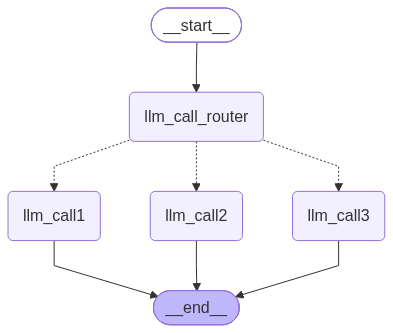

In [17]:
display(Image(router_workflow.get_graph().draw_mermaid_png()))

In [18]:
state = router_workflow.invoke({"input": "Write me a joke about cats"})  
print(state["output"])

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Here's one for you:**

Why did the cat sit on the computer?

Because it wanted to be a **purr-grammer**!
